## Imports

In [2]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

## Télécharger le réseau routier d'Abidjan

In [3]:
# Télécharger uniquement les routes carrossables
G = ox.graph_from_place("Abidjan, Côte d'Ivoire", network_type="drive")

print(f"Nombre de nœuds (intersections) : {len(G.nodes)}")
print(f"Nombre d'arêtes (segments de route) : {len(G.edges)}")

Nombre de nœuds (intersections) : 52944
Nombre d'arêtes (segments de route) : 145963


## Visualisation rapide

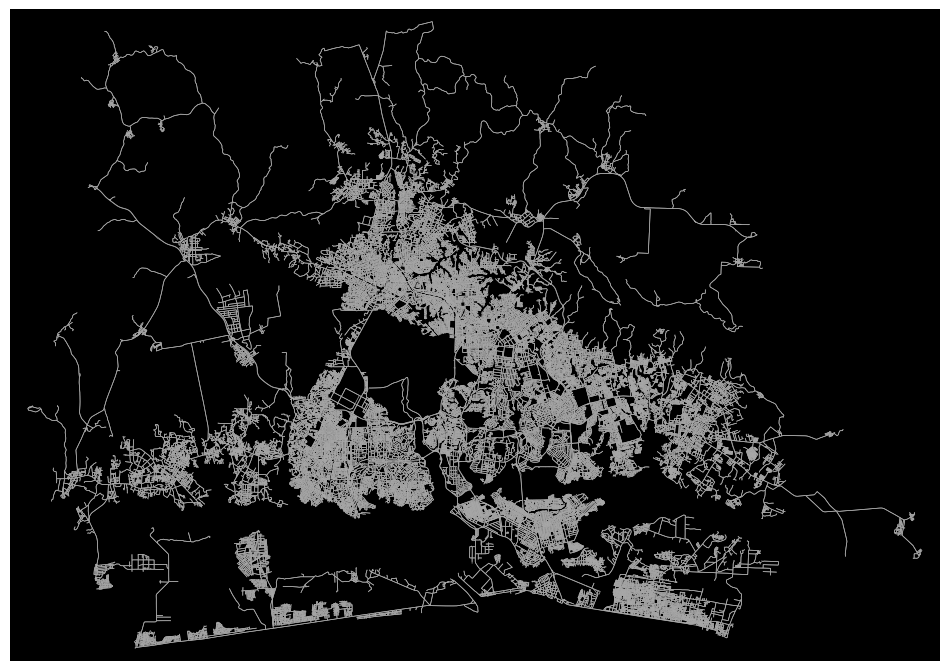

Image sauvegardée !


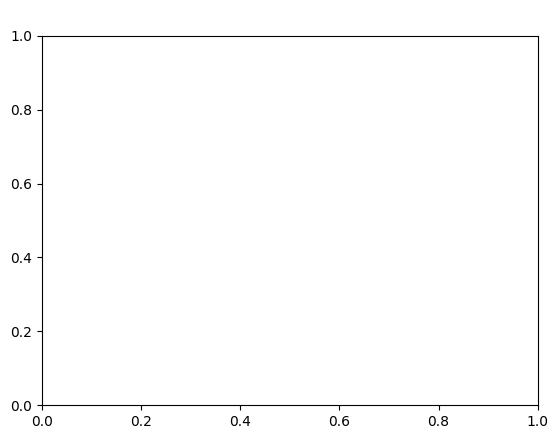

In [5]:
fig, ax = ox.plot_graph(G, figsize=(12, 10), 
                         node_size=0,
                         edge_color="#AAAAAA",
                         edge_linewidth=0.5,
                         bgcolor="black")
plt.title("Réseau routier d'Abidjan", color="white", fontsize=16)
import os

# Créer le dossier outputs s'il n'existe pas
os.makedirs("../outputs", exist_ok=True)

plt.savefig("../outputs/reseau_abidjan.png", dpi=150, bbox_inches="tight")
print("Image sauvegardée !")

## Convertir en GeoDataFrame et sauvegarder

In [6]:
# Convertir le graphe en couches géographiques
nodes, edges = ox.graph_to_gdfs(G)

print(edges.columns.tolist())  # voir les colonnes disponibles
print(edges[['name', 'highway', 'length']].head(10))

# Sauvegarder
edges.to_file("../data/processed/abidjan_roads.gpkg", driver="GPKG")
print(" Fichier sauvegardé !")

['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length', 'maxspeed', 'ref', 'geometry', 'bridge', 'junction', 'access', 'tunnel', 'width']
                                                           name  \
u        v          key                                           
33320931 339026004  0                            Rue Abrogouama   
         4191725501 0            Boulevard Jean-Baptiste Mockey   
33320941 338990981  0                                       NaN   
         4455488581 0    Boulevard Félix Houphouët Boigny (FHB)   
33320944 339029839  0                         Avenue Noel Nemin   
         2998620916 0    Boulevard Félix Houphouët Boigny (FHB)   
33320962 243770916  0                         Autoroute du Nord   
33320976 243780434  0                                       NaN   
         243780442  0                         Autoroute du Nord   
33320984 338371485  0                                       NaN   

                               highway     

## Charger les limites d'Abidjan

In [8]:
import geopandas as gpd

# Charger le niveau 3 (communes)
admin = gpd.read_file("../data/raw/gadm41_CIV_3.shp")

# Voir les colonnes disponibles
print(admin.columns.tolist())
print(admin[['NAME_1', 'NAME_2', 'NAME_3']].head(20))

['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']
           NAME_1            NAME_2        NAME_3
0         Abidjan           Abidjan       Abidjan
1   Bas-Sassandra            Gbôkle        Fresco
2   Bas-Sassandra            Gbôkle     Sassandra
3   Bas-Sassandra              Nawa          Buyo
4   Bas-Sassandra              Nawa         Guéyo
5   Bas-Sassandra              Nawa        Méagui
6   Bas-Sassandra              Nawa        Oupoyo
7   Bas-Sassandra              Nawa        Soubré
8   Bas-Sassandra         San-Pédro     San-Pedro
9   Bas-Sassandra         San-Pédro         Tabou
10          Comoé  Indénié-Djuablin    Abengourou
11          Comoé  Indénié-Djuablin  Agnibilékrou
12          Comoé  Indénié-Djuablin        Bettié
13          Comoé         Sud Comoé       Aboisso
14          Comoé         Sud Comoé        Adiake
15          Comoé

## Filtrer et visualiser Abidjan

Nombre de communes : 1
['Abidjan']


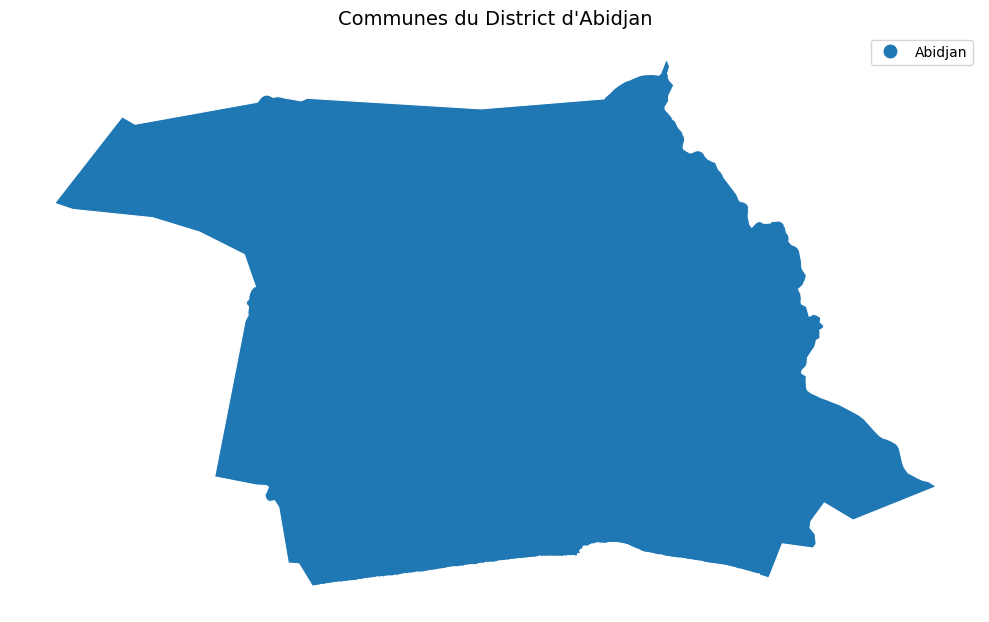

Communes chargées !


In [9]:
# Filtrer uniquement le district d'Abidjan
abidjan = admin[admin['NAME_1'] == 'Abidjan']

print(f"Nombre de communes : {len(abidjan)}")
print(abidjan['NAME_3'].tolist())

# Visualiser les communes
fig, ax = plt.subplots(figsize=(10, 8))
abidjan.plot(ax=ax, 
             column='NAME_3',
             cmap='tab20',
             edgecolor='white',
             linewidth=0.8,
             legend=True)

plt.title("Communes du District d'Abidjan", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("../outputs/communes_abidjan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Communes chargées !")

## Recharge avec CIV_4

In [10]:
# Utiliser le niveau 4 (plus précis)
admin = gpd.read_file("../data/raw/gadm41_CIV_4.shp")

# Voir les colonnes
print(admin.columns.tolist())
print(admin[['NAME_1', 'NAME_2', 'NAME_3', 'NAME_4']].head(20))

['GID_4', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'GID_2', 'NAME_2', 'GID_3', 'NAME_3', 'NAME_4', 'VARNAME_4', 'TYPE_4', 'ENGTYPE_4', 'CC_4', 'geometry']
           NAME_1            NAME_2      NAME_3         NAME_4
0         Abidjan           Abidjan     Abidjan  Abidjan-Ville
1         Abidjan           Abidjan     Abidjan         Anyama
2         Abidjan           Abidjan     Abidjan    Bingerville
3         Abidjan           Abidjan     Abidjan         Songon
4   Bas-Sassandra            Gbôkle      Fresco         Fresco
5   Bas-Sassandra            Gbôkle   Sassandra      Sassandra
6   Bas-Sassandra              Nawa        Buyo           Buyo
7   Bas-Sassandra              Nawa        Buyo        Dapéoua
8   Bas-Sassandra              Nawa       Guéyo          Gueyo
9   Bas-Sassandra              Nawa      Méagui         Méagui
10  Bas-Sassandra              Nawa      Oupoyo      Gnamangui
11  Bas-Sassandra              Nawa      Soubré      Gnamangui
12  Bas-Sassandra           

## Filtrer et visualiser les communes d'Abidjan

Nombre de communes : 4
Communes : ['Abidjan-Ville', 'Anyama', 'Bingerville', 'Songon']


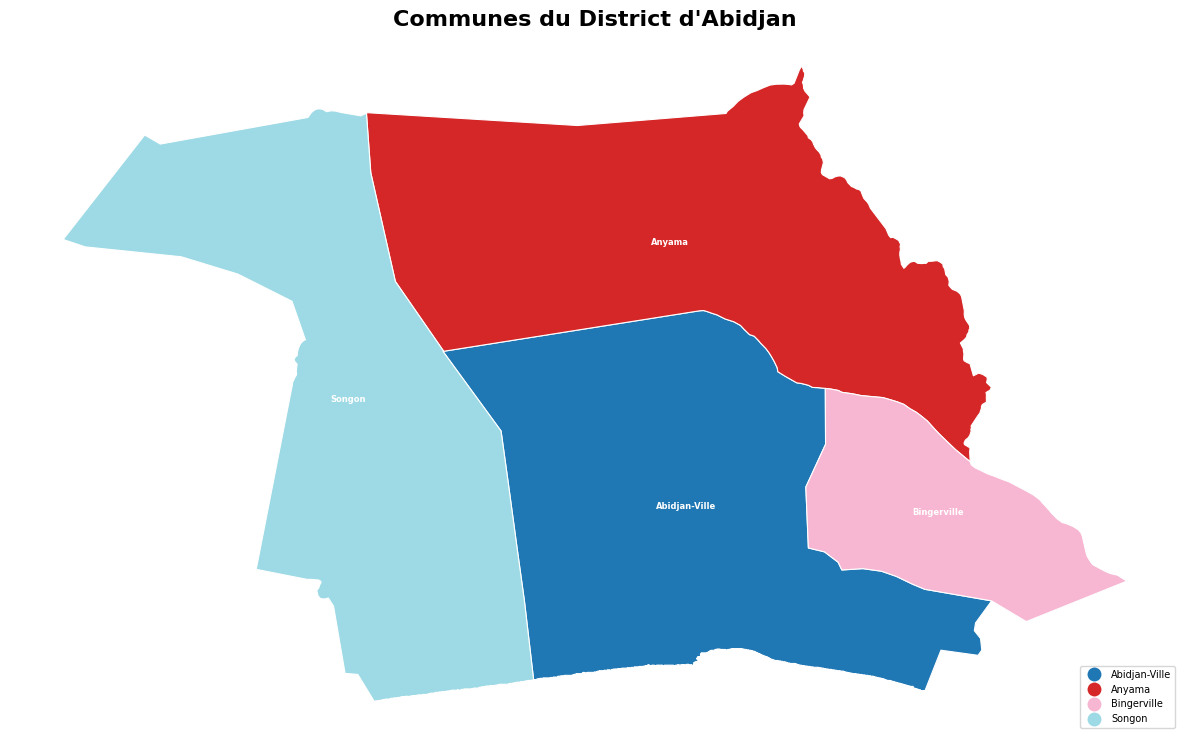

Communes d'Abidjan chargées !


In [11]:
# Filtrer Abidjan avec NAME_1
abidjan = admin[admin['NAME_1'] == 'Abidjan'].copy()

print(f"Nombre de communes : {len(abidjan)}")
print("Communes :", abidjan['NAME_4'].tolist())

# Visualiser avec couleurs distinctes
fig, ax = plt.subplots(figsize=(12, 10))

abidjan.plot(ax=ax,
             column='NAME_4',
             cmap='tab20',
             edgecolor='white',
             linewidth=0.8,
             legend=True,
             legend_kwds={'loc': 'lower right', 'fontsize': 7})

# Ajouter les noms des communes sur la carte
for idx, row in abidjan.iterrows():
    ax.annotate(row['NAME_4'], 
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                fontsize=6, ha='center', color='white', fontweight='bold')

plt.title("Communes du District d'Abidjan", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("../outputs/communes_abidjan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Communes d'Abidjan chargées !")